In [ ]:
# =====================
# 1. IMPORT LIBRARIES
# =====================
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import subprocess
from imblearn.over_sampling import SMOTE

print("Libraries loaded")


Libraries loaded


In [ ]:
#==============================
# 2. RUN EXISTING PREPROCESS.PY
#==============================
subprocess.run(["python", "preprocess.py"])
print("Preprocessing completed")

Preprocessing completed


In [ ]:
# =====================
# 3. LOAD DATASET
# =====================
file_path = Path().resolve().parent / "data" / "processed" / "churn_processed.csv"
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,-1.009430,-0.440327,1.035617,-0.652305,-1.280248,-3.056334,0.062666,-1.183614,-0.917837,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,-1.161694,-0.994194,0
1,0.990658,-0.440327,-0.965608,-0.652305,0.064303,0.327189,-0.991564,-1.183614,1.408012,-1.028998,1.245441,-0.924267,-1.112632,-1.121501,0.373926,-1.206361,1.336636,-0.260878,-0.173740,0
2,0.990658,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,-1.183614,1.408012,1.242875,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,1.336636,-0.363923,-0.959649,1
3,0.990658,-0.440327,-0.965608,-0.652305,0.512486,-3.056334,0.062666,-1.183614,1.408012,-1.028998,1.245441,1.396963,-1.112632,-1.121501,0.373926,-1.206361,-1.473857,-0.747850,-0.195248,0
4,-1.009430,-0.440327,-0.965608,-0.652305,-1.239504,0.327189,-0.991564,0.172835,-0.917837,-1.028998,-1.026988,-0.924267,-1.112632,-1.121501,-0.826735,0.828939,0.399805,0.196178,-0.940457,1


In [ ]:
# =============
# 4. SPLIT DATA
# =============

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts())



Train: (5625, 19)
Test: (1407, 19)
Churn
0    4130
1    1495
Name: count, dtype: int64


In [ ]:
# ======================
# 5. DECISION TREE MODEL
# ======================
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained")

#==========
#PREDICTION
#==========

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

Model trained


In [ ]:
# =============
# 6. EVALUATION
# =============
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.775408670931059
Precision: 0.5838150289017341
Recall: 0.5401069518716578
F1 Score: 0.5611111111111111

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1033
           1       0.58      0.54      0.56       374

    accuracy                           0.78      1407
   macro avg       0.71      0.70      0.71      1407
weighted avg       0.77      0.78      0.77      1407



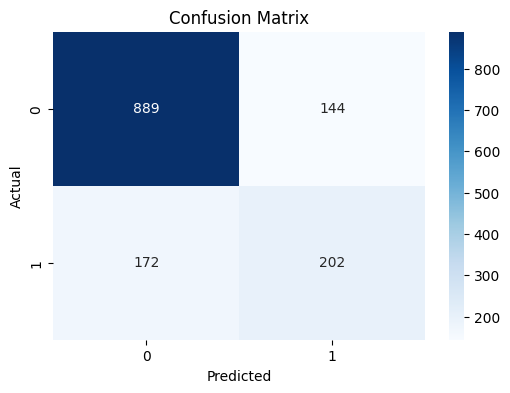

In [ ]:
# =====================
# 7. CONFUSION MATRIX
# =====================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

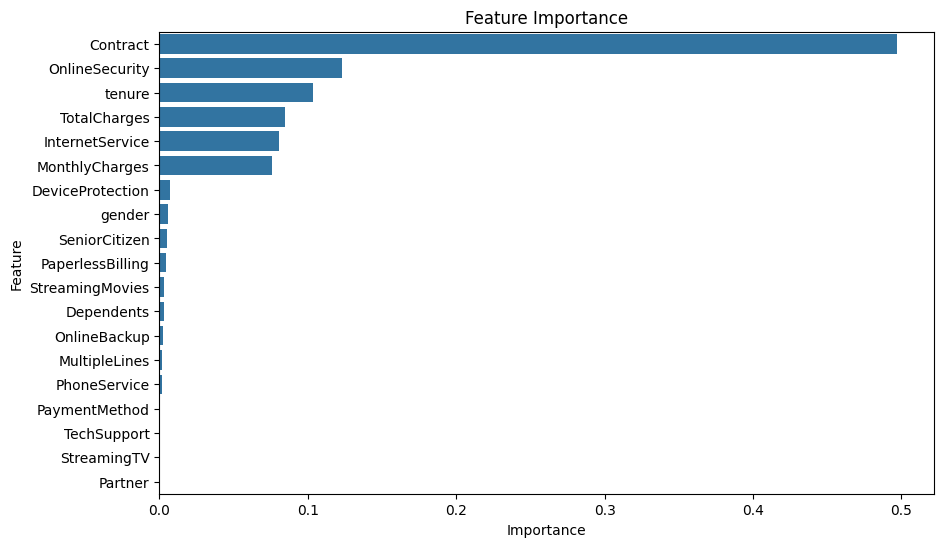

In [ ]:
# =====================
# 8. FEATURE IMPORTANCE
# =====================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance)
plt.title("Feature Importance")
plt.show()